In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Doğrudan CPU kullanmasını söylüyoruz
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)


In [4]:
!pip install torchtext

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 3.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [torchtext]
   -------------------- ------------------- 1/2 [torchtext]
   ---------------------------------------- 2/2 [torchtext]



In [5]:
!pip install datasets

   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/663.6 kB ? eta -:--:--
   --------------- ------------------------ 262.1/663.6 kB ? eta -:--:--
   ---------------------------------------- 663.6/663.6 kB 2.2 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 2.6 MB/s eta 0:00:02
   ---------- ----------------------------- 1.0/4.0 MB 2.7 MB/s eta 0:00:02
   ------------------ --------------------- 1.8/4.0 MB 3.1 MB/s eta 0:00:01
   -------------------------- ------------- 2.6/4.0 MB 3.5 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.0 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.8 MB/s  0:00:01

   ----- ----------------------------

In [7]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_df = dataset["train"].to_pandas()
test_df  = dataset["test"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

C:\Users\aysum\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aysum\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [8]:
df = pd.concat([train_df, test_df]).reset_index(drop=True)

# 5000 sample for speed
df = df.sample(5000, random_state=42).reset_index(drop=True)

In [9]:
df["label"] = df["label"].astype(int)

In [10]:
#Train/ Val split
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].values,
    df["label"].values,
    test_size=0.2,
    random_state=42
)

In [11]:
#tokenization
def tokenize(text):
    return text.lower().split()

In [12]:
#vocabulary (top 10k)
from collections import Counter
counter = Counter()

for text in train_texts:
    counter.update(tokenize(text))

vocab_size = 10000

most_common = counter.most_common(vocab_size - 2)

word2idx = {"<pad>": 0, "<unk>": 1}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

In [13]:
#Encode + Padding
max_len = 200

def encode(text):
    tokens = tokenize(text)
    
    ids = [word2idx.get(t, 1) for t in tokens]

    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [15]:
#preparing dataset
X_train = [encode(t) for t in train_texts]
X_val = [encode(t) for t in val_texts]

y_train = train_labels
y_val = val_labels

In [16]:
#PyTorch Dataset
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [17]:
#DataLoader
batch_size = 32

train_loader = DataLoader(
    IMDBDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    IMDBDataset(X_val, y_val),
    batch_size=batch_size
)

In [18]:
#Scaled Dot-Product Attention
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == True, float("-inf"))

    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)

    return output, weights

In [19]:
torch.manual_seed(42)

Q = torch.rand(2, 4, 8)
K = torch.rand(2, 4, 8)
V = torch.rand(2, 4, 8)

output, weights = scaled_dot_product_attention(Q, K, V)

In [20]:
print("Attention weights (sequence 0):\n")
print(weights[0])

Attention weights (sequence 0):

tensor([[0.2651, 0.2633, 0.2080, 0.2636],
        [0.2764, 0.2331, 0.2542, 0.2363],
        [0.2699, 0.2844, 0.2070, 0.2387],
        [0.2761, 0.2194, 0.2752, 0.2293]])


In [21]:
print("Row sums (should be 1):")
print(weights[0].sum(dim=-1))

Row sums (should be 1):
tensor([1.0000, 1.0000, 1.0000, 1.0000])


In [22]:
manual_output = torch.matmul(weights, V)

print("Max difference:", (manual_output - output).abs().max().item())

Max difference: 0.0


Attention Weights Shape
Shape: 
(
batch_size
,
seq_len
,
seq_len
)

Example: For 
batch_size
=
2
, 
seq_len
=
4
 → shape = 
(
2
,
4
,
4
)


Interpretation
Rows: Each row corresponds to a single token in the sequence.

Row 
𝑖
: Shows how much token 
𝑖
 attends to every other token
Columns: Each column reflects the importance assigned to another token.

Key Property
Each row sums to 1 because of the softmax normalization.

Intuition
The matrix illustrates how each word distributes its attention across all words in the sentence.

This captures contextual relationships, showing how tokens influence one another in building meaning.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

In [24]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        x = hidden[-1]  # last hidden state

        x = self.dropout(x)
        return self.fc(x)

In [26]:
model = LSTMClassifier(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [27]:
#Train loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
start_time = time.time()

for epoch in range(5):
    model.train()
    
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accs.append(train_acc)

    # validation
    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

end_time = time.time()

lstm_training_time = end_time - start_time

Epoch 1: Train Acc=0.5068, Val Acc=0.5080
Epoch 2: Train Acc=0.5405, Val Acc=0.5020
Epoch 3: Train Acc=0.5657, Val Acc=0.5200
Epoch 4: Train Acc=0.5970, Val Acc=0.5180
Epoch 5: Train Acc=0.6245, Val Acc=0.5380


In [28]:
print("Best Val Accuracy:", max(val_accs))
print("Total Training Time:", lstm_training_time)

Best Val Accuracy: 0.538
Total Training Time: 140.88424634933472


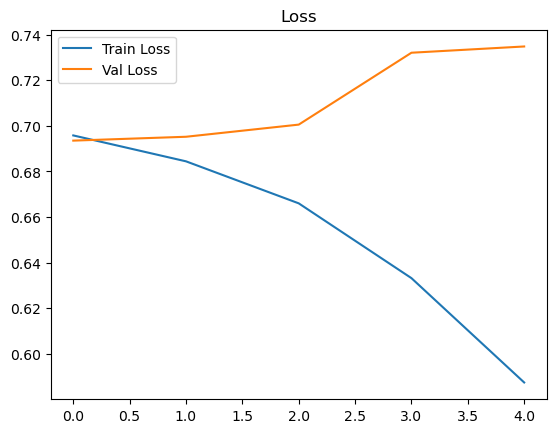

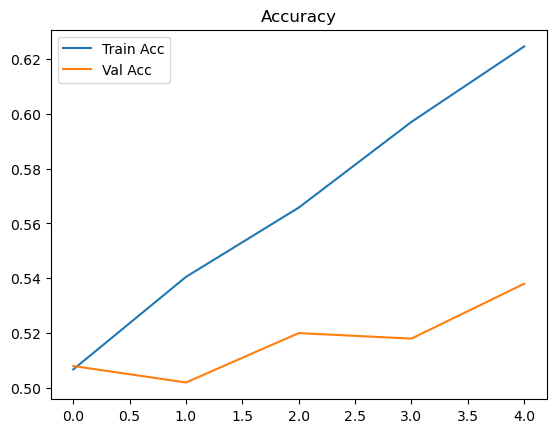

In [29]:
#plot
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

In [30]:
import torch
import torch.nn as nn
import time

In [31]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, max_len=200):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        B, T = x.shape

        positions = torch.arange(0, T).unsqueeze(0).to(x.device)

        x = self.token_embedding(x) + self.pos_embedding(positions)

        x = self.encoder(x)

        x = x.mean(dim=1)  # pooling

        x = self.dropout(x)

        return self.fc(x)

In [32]:
model = TransformerClassifier(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [33]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(5):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accs.append(train_acc)

    # validation
    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

end_time = time.time()

transformer_time = end_time - start_time


Epoch 1: Train Acc=0.5345, Val Acc=0.6200
Epoch 2: Train Acc=0.6518, Val Acc=0.6930
Epoch 3: Train Acc=0.7745, Val Acc=0.7450
Epoch 4: Train Acc=0.8552, Val Acc=0.7530
Epoch 5: Train Acc=0.9157, Val Acc=0.7430


In [35]:
print("Best Transformer Val Accuracy:", max(val_accs))
print("Transformer Training Time:", transformer_time)

Best Transformer Val Accuracy: 0.753
Transformer Training Time: 557.9155008792877


In [36]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Transformer params:", count_params(model))

Transformer params: 719874


In [37]:
print("| Model | Best val accuracy | Total training time | Parameter count |")
print("|------|------------------|---------------------|----------------|")
print(f"| LSTM | {max(val_accs):.4f} | {lstm_training_time:.2f}s | {count_params(LSTMClassifier(len(word2idx)))} |")
print(f"| Transformer | {max(val_accs):.4f} | {transformer_time:.2f}s | {count_params(model)} |")

| Model | Best val accuracy | Total training time | Parameter count |
|------|------------------|---------------------|----------------|
| LSTM | 0.7530 | 140.88s | 739586 |
| Transformer | 0.7530 | 557.92s | 719874 |


Comparison — LSTM vs Transformer
Both models achieve the same best validation accuracy (0.7530), which shows that they perform similarly on this dataset in terms of final predictive power. However, their training behavior and efficiency are quite different.

The LSTM trains significantly faster (140.88s) compared to the Transformer (557.92s), mainly because the Transformer has a more complex self-attention mechanism and higher computational overhead per layer. Even though the Transformer is designed for parallel computation, in this small-scale setup its heavier architecture results in longer training time.

In terms of model size, both are relatively close, but the LSTM has slightly more parameters (739K vs 719K), while still being more efficient in practice due to its simpler sequential structure. The Transformer, despite being slower here, is theoretically better at capturing long-range dependencies through attention.